focused on ORGANIZATION and also continued factor analysis 

In [1]:
from IPython.display import display #deadass i think this does nothing but i dont wanna remove it 

from mlflow.models.signature import infer_signature

from src.features import feature_encoder, raw_data_loader

from src.modeling.fa_tuning import (
    build_best_factor_analysis_pipeline,
    tune_factor_analysis_rotation,
)

from src.plots import parallel_analysis

from src.utils.data_utils import convert_ahi

import xgboost as xgb

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

import mlflow

import pandas as pd

import numpy as np

import json

import os


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ["MLFLOW_EXPERIMENT_NAME"] = "2.3-jp-feature-engineering"

mlflow.set_tracking_uri("file:///Users/jack/Repos/apnea-predictor/mlruns")
mlflow.set_experiment(os.getenv("MLFLOW_EXPERIMENT_NAME", "default_experiment"))

/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:///Users/jack/Repos/apnea-predictor/mlruns/825373606965551241', creation_time=1776728062398, experiment_id='825373606965551241', last_update_time=1776728062398, lifecycle_stage='active', name='2.3-jp-feature-engineering', tags={}, workspace='default'>

In [3]:
df = raw_data_loader.load_and_clean_raw("..")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1880 entries, 0 to 1880
Columns: 409 entries, ('participants_age', 'modified_dem_0110', 'demographics') to ('apnea_hypopnea_index', 'ahi', 'output')
dtypes: Int64(8), boolean(1), datetime64[ns](19), float64(379), object(2)
memory usage: 5.9+ MB


In [4]:
df = feature_encoder.encode_features(df)

df = df.drop(columns=['ess_total_score', 'isi_total_score'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1687 entries, 0 to 1686
Columns: 147 entries, age to dream_recall_frequency_rarely_or_never
dtypes: float64(136), int64(11)
memory usage: 1.9 MB


In [5]:
rotations = [
    "varimax",  # (orthogonal rotation)
    "promax",  # (oblique rotation)
    "oblimin",  # (oblique rotation)
    "oblimax",  # (orthogonal rotation)
    "quartimin",  # (oblique rotation)
    "quartimax",  # (orthogonal rotation)
    "equamax"  # (orthogonal rotation)
]


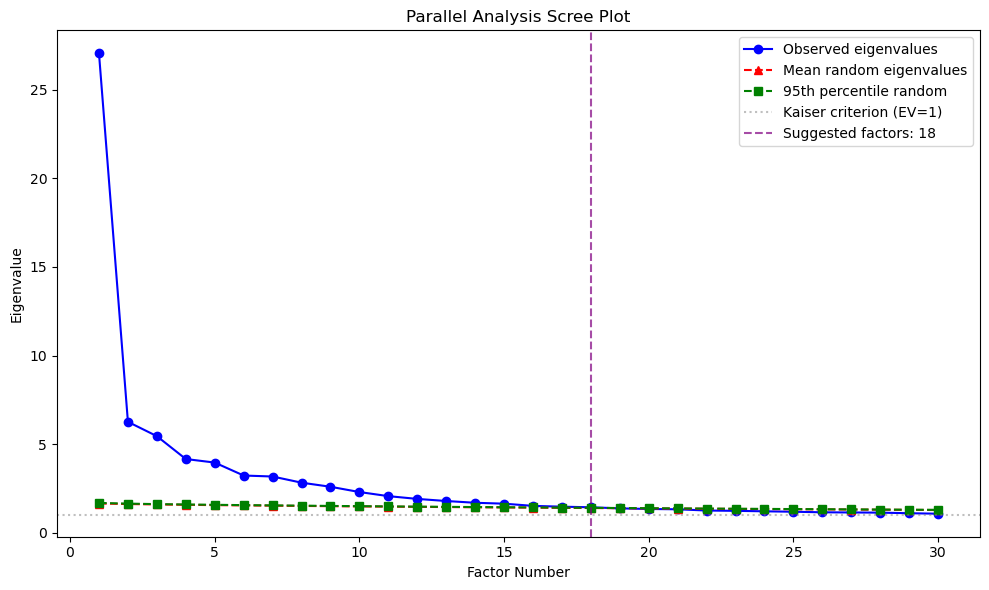


Parallel analysis suggests 18 factors


In [6]:
parallel_analysis(df.drop(columns=["ahi"]), n_iterations=1000)  # parallel analysis suggests 18 factors

In [7]:
BEST_PARAMS_PATH = "../data/interim/best_fa_xgb_params.json"

X = df.drop(columns=["ahi"])
y = convert_ahi(df["ahi"])

rotations = [ # im pretty sure varimax is the best definitivley so maybe on reruns just remove this part from the cv
    "varimax",  # (orthogonal rotation)
    "promax",  # (oblique rotation)
    "oblimin",  # (oblique rotation)
    "oblimax",  # (orthogonal rotation)
    "quartimin",  # (oblique rotation)
    "quartimax",  # (orthogonal rotation)
    "equamax"  # (orthogonal rotation)
]

xgb_search_space = {
    "n_estimators": {"type": "int", "low": 100, "high": 500, "step": 50},
    "max_depth": {"type": "int", "low": 3, "high": 8},
    "min_child_weight": {"type": "int", "low": 1, "high": 10},
    "learning_rate": {"type": "float", "low": 0.01, "high": 0.3, "log": True},
    "subsample": {"type": "float", "low": 0.6, "high": 1.0, "step": 0.1},
    "colsample_bytree": {"type": "float", "low": 0.6, "high": 1.0, "step": 0.1},
    "gamma": {"type": "float", "low": 0.0, "high": 5.0, "step": 0.5},
}


search_dataset = mlflow.data.from_pandas(
    pd.concat([X, y.rename("ahi")], axis=1),
    name="2.3-sleep-apnea-fa-xgb-search",
    targets="ahi",
)


BEST_PARAMS_FOUND = True # manual set casue this takes a while to run

if not BEST_PARAMS_FOUND:
    with mlflow.start_run(run_name="joint_fa_xgb_optuna_search"):

        mlflow.log_input(search_dataset, context="train")

        mlflow.set_tag("model_type", "factor-analysis-xgboost-pipeline")

        mlflow.set_tag("search_type", "joint_fa_xgb_optuna")

        mlflow.log_param("scoring", "roc_auc")

        mlflow.log_param("n_splits", 5)

        mlflow.log_param("n_trials", 40)

        mlflow.log_param("fixed_n_factors", 18)

        mlflow.log_param("candidate_rotations", ",".join(rotations))

        mlflow.log_dict(xgb_search_space, "xgb_search_space.json")

        tuning_result = tune_factor_analysis_rotation(
            X,
            y,
            rotations=rotations,
            n_factors=18,
            n_splits=5,
            n_trials=40,
            scoring="roc_auc",
            xgb_search_space=xgb_search_space,
            random_state=42,
        )

        best_fa_pipeline = build_best_factor_analysis_pipeline(tuning_result)

        best_fa_pipeline.fit(X, y)

        best_xgb_params = {
            key: value
            for key, value in tuning_result.best_params.items()
            if key not in {"rotation", "n_factors"}
        }

        mlflow.log_param("best_rotation", tuning_result.best_rotation)

        mlflow.log_param("best_n_factors", tuning_result.best_params.get("n_factors", 18))

        mlflow.log_params({f"best_{key}": value for key, value in best_xgb_params.items()})

        mlflow.log_metric("best_mean_cv_roc_auc", tuning_result.best_score)

        mlflow.log_metric("completed_trials", len(tuning_result.trial_results))

        mlflow.log_text(
            tuning_result.rotation_summary.to_csv(index=False),
            "rotation_summary.csv",
        )

        mlflow.log_text(
            tuning_result.trial_results.to_csv(index=False),
            "trial_results.csv",
        )

        signature = infer_signature(X, best_fa_pipeline.predict(X))

        mlflow.sklearn.log_model(
            best_fa_pipeline,
            name="best_fa_xgb_pipeline",
            signature=signature,
        )

        # Save best params to disk so future runs skip the search
        with open(BEST_PARAMS_PATH, "w") as f:
            json.dump(tuning_result.best_params, f, indent=2)

    print(f"Best rotation: {tuning_result.best_rotation}")

    print(f"Best n_factors: {tuning_result.best_params.get('n_factors', 18)}")

    print(f"Best mean CV ROC-AUC: {tuning_result.best_score:.4f}")

    print("Best XGBoost params:")

    print(best_xgb_params)

    display(tuning_result.rotation_summary)

    display(tuning_result.trial_results)


# Always load from disk so downstream cells work regardless of BEST_PARAMS_FOUND
from types import SimpleNamespace

with open(BEST_PARAMS_PATH) as f:
    _saved_params = json.load(f)

best_fa_pipeline = build_best_factor_analysis_pipeline(
    SimpleNamespace(
        best_params=_saved_params,
        best_rotation=_saved_params.get("rotation"),
    )
)
best_xgb_params = {k: v for k, v in _saved_params.items() if k not in {"rotation", "n_factors"}}

print(f"Loaded best_rotation : {_saved_params.get('rotation')}")
print(f"Loaded best_n_factors: {_saved_params.get('n_factors', 18)}")
print(f"Loaded XGBoost params : {best_xgb_params}")


Loaded best_rotation : varimax
Loaded best_n_factors: 18
Loaded XGBoost params : {'n_estimators': 450, 'max_depth': 6, 'min_child_weight': 9, 'learning_rate': 0.016099070709256574, 'subsample': 0.6, 'colsample_bytree': 1.0, 'gamma': 5.0}


the cell above does hyperamater searching on the entire pipeline and lowkey i don't know
why is set it up this way but i mean i guess its something ill figure it out in the
future and perhaps just save a model for parameters and then mess with the datasets
the dataaset is much more important anyway

as i am running the brother above it seems like all the difference is quite marginal

Saving just in case it gets overrun
Best rotation: varimax
Best n_factors: 18
Best mean CV ROC-AUC: 0.5314
Best XGBoost params:
{'n_estimators': 450, 'max_depth': 6, 'min_child_weight': 9, 'learning_rate': 0.016099070709256574, 'subsample': 0.6, 'colsample_bytree': 1.0, 'gamma': 5.0}

In [8]:
mlflow.xgboost.autolog()
mlflow.sklearn.autolog()

In [9]:
from mlflow.artifacts import download_artifacts
from mlflow.tracking import MlflowClient
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, accuracy_score, confusion_matrix
import shap
import matplotlib.pyplot as plt
import numpy as np
import tempfile
import os
from xgboost import XGBClassifier

In [10]:

df = df.copy()
X = df.drop(columns=["ahi"])
y = convert_ahi(df["ahi"])

fa_step = best_fa_pipeline.steps[0][1]      # factor analyzer
xgb_step = best_fa_pipeline.steps[-1][1]    # classifier (XGBClassifier)

# Use holdout data for explanations
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_fa_pipeline.fit(X_train, y_train)

# Transform into factor space (what XGBoost actually sees)
X_bg = X_train.sample(min(200, len(X_train)), random_state=42)
X_eval = X_test.sample(min(500, len(X_test)), random_state=42)

X_bg_fa = fa_step.transform(X_bg)
X_eval_fa = fa_step.transform(X_eval)

fa_cols = [f"FA_{i+1}" for i in range(X_eval_fa.shape[1])]

# Build SHAP explainer on the XGB model
explainer = shap.TreeExplainer(xgb_step)
shap_values = explainer.shap_values(X_eval_fa)

# Handle binary/multiclass output shape differences
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_plot = shap_values

preds = best_fa_pipeline.predict(X_test)
proba = best_fa_pipeline.predict_proba(X_test)
if proba.shape[1] == 2:
    roc_auc = roc_auc_score(y_test, proba[:, 1])
else:
    roc_auc = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")
accuracy = accuracy_score(y_test, preds)
class_report = classification_report(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

with mlflow.start_run(run_name="tuned_fa_xgb_shap_eval"):
    mlflow.log_param("pipeline", "tuned_fa_xgb")
    mlflow.log_param("rotation", best_xgb_params.get("rotation", "varimax"))
    mlflow.log_param("n_factors", 18)
    mlflow.log_params({f"xgb_{k}": v for k, v in best_xgb_params.items()})

    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("accuracy", accuracy)

    # 1) SHAP summary (beeswarm)
    plt.figure()
    shap.summary_plot(shap_values_plot, X_eval_fa, feature_names=fa_cols, show=False)
    mlflow.log_figure(plt.gcf(), "shap/summary_beeswarm.png")
    plt.close()

    # 2) SHAP summary (bar importance)
    plt.figure()
    shap.summary_plot(shap_values_plot, X_eval_fa, feature_names=fa_cols, plot_type="bar", show=False)
    mlflow.log_figure(plt.gcf(), "shap/summary_bar.png")
    plt.close()

    # 3) Force plot for one sample as HTML artifact
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[1] if np.ndim(expected_value) > 0 and len(expected_value) > 1 else np.ravel(expected_value)[0]

    force = shap.force_plot(
        expected_value,
        shap_values_plot[0],
        X_eval_fa.iloc[0],
        feature_names=fa_cols,
        matplotlib=False,
    )

    with tempfile.TemporaryDirectory() as td:
        force_path = os.path.join(td, "force_plot_sample0.html")
        shap.save_html(force_path, force)
        mlflow.log_artifact(force_path, artifact_path="shap")

    mlflow.log_text(class_report, "classification_report.txt")

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(class_report)
print(conf_matrix)


2026/04/21 15:14:28 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '6da13b5674f14ba9a9ac1134fbde7bcf', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow


2026/04/21 15:14:28 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/21 15:14:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/jack/Repos/apnea-p

ROC-AUC: 0.5320
Accuracy: 0.6598
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       115
           1       0.66      1.00      0.80       223

    accuracy                           0.66       338
   macro avg       0.33      0.50      0.40       338
weighted avg       0.44      0.66      0.52       338

[[  0 115]
 [  0 223]]


the hyperparameter selections end up only predicting 1 class -_-

In [11]:
factor_analyzer = best_fa_pipeline.steps[0][1]

factor_analyzer.get_top_loadings()

Top loadings for Factor_1:
fati_interferes_with_phys_function_fss       0.832786
fati_prevents_sustained_phys_func_fss        0.824393
fati_top_three_disabling_sympts_fss          0.819425
fati_causes_freq_probs_for_me_fss            0.815738
fati_interferes_with_responsibilities_fss    0.812848
fati_interferes_with_work_fam_social_fss     0.798713
i_am_easily_fati_fss                         0.783652
lower_motivation_when_fati_fss               0.586320
Name: Factor_1, dtype: float64


Top loadings for Factor_2:
not_able_to_control_worrying_freq_gad     0.818536
worry_too_much_diff_things_freq_gad       0.781222
feeling_anxious_freq_gad                  0.728557
feel_bad_abt_yourself_freq_phq            0.699199
feel_as_if_awful_might_happen_freq_gad    0.687949
feel_depressed_freq_phq                   0.680994
trouble_relaxing_freq_gad                 0.638659
easily_annoyed_freq_gad                   0.565541
Name: Factor_2, dtype: float64


Top loadings for Factor_3:
ess_chance_of

In [12]:
non_tuned_pipeline = build_best_factor_analysis_pipeline(
    SimpleNamespace(
        best_params={
            "rotation": "varimax",
            "n_factors": 18,
        },
        best_rotation="varimax",
    )
)   

In [13]:

df = df.copy()
X = df.drop(columns=["ahi"])
y = convert_ahi(df["ahi"])

fa_step = non_tuned_pipeline.steps[0][1]      # factor analyzer
xgb_step = non_tuned_pipeline.steps[-1][1]    # classifier (XGBClassifier)

# Use holdout data for explanations
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

non_tuned_pipeline.fit(X_train, y_train)

# Transform into factor space (what XGBoost actually sees)
X_bg = X_train.sample(min(200, len(X_train)), random_state=42)
X_eval = X_test.sample(min(500, len(X_test)), random_state=42)

X_bg_fa = fa_step.transform(X_bg)
X_eval_fa = fa_step.transform(X_eval)

fa_cols = [f"FA_{i+1}" for i in range(X_eval_fa.shape[1])]

# Build SHAP explainer on the XGB model
explainer = shap.TreeExplainer(xgb_step)
shap_values = explainer.shap_values(X_eval_fa)

# Handle binary/multiclass output shape differences
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_values_plot = shap_values

preds = non_tuned_pipeline.predict(X_test)
proba = non_tuned_pipeline.predict_proba(X_test)
if proba.shape[1] == 2:
    roc_auc = roc_auc_score(y_test, proba[:, 1])
else:
    roc_auc = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")
accuracy = accuracy_score(y_test, preds)
class_report = classification_report(y_test, preds)
conf_matrix = confusion_matrix(y_test, preds)

with mlflow.start_run(run_name="non_tuned_fa_xgb_shap_eval"):
    mlflow.log_param("pipeline", "non_tuned_fa_xgb")
    mlflow.log_param("rotation", "varimax")
    mlflow.log_param("n_factors", 18)

    mlflow.log_metric("roc_auc", roc_auc)
    mlflow.log_metric("accuracy", accuracy)

    # 1) SHAP summary (beeswarm)
    plt.figure()
    shap.summary_plot(shap_values_plot, X_eval_fa, feature_names=fa_cols, show=False)
    mlflow.log_figure(plt.gcf(), "shap/summary_beeswarm.png")
    plt.close()

    # 2) SHAP summary (bar importance)
    plt.figure()
    shap.summary_plot(shap_values_plot, X_eval_fa, feature_names=fa_cols, plot_type="bar", show=False)
    mlflow.log_figure(plt.gcf(), "shap/summary_bar.png")
    plt.close()

    # 3) Force plot for one sample as HTML artifact
    expected_value = explainer.expected_value
    if isinstance(expected_value, (list, np.ndarray)):
        expected_value = expected_value[1] if np.ndim(expected_value) > 0 and len(expected_value) > 1 else np.ravel(expected_value)[0]

    force = shap.force_plot(
        expected_value,
        shap_values_plot[0],
        X_eval_fa.iloc[0],
        feature_names=fa_cols,
        matplotlib=False,
    )

    with tempfile.TemporaryDirectory() as td:
        force_path = os.path.join(td, "force_plot_sample0.html")
        shap.save_html(force_path, force)
        mlflow.log_artifact(force_path, artifact_path="shap")

    mlflow.log_text(class_report, "classification_report.txt")

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(class_report)
print(conf_matrix)


2026/04/21 15:14:34 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '187d140671bb4e79a347e2a48cf869d5', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/04/21 15:14:34 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Inte

ROC-AUC: 0.5221
Accuracy: 0.6450
              precision    recall  f1-score   support

           0       0.43      0.14      0.21       115
           1       0.67      0.91      0.77       223

    accuracy                           0.64       338
   macro avg       0.55      0.52      0.49       338
weighted avg       0.59      0.64      0.58       338

[[ 16  99]
 [ 21 202]]


despite being also not very good the non-tuned model is a lot better by nature of 
being able to predict more than one class

most important features:
FA_1,
FA_3,
FA_2,
FA_10,
FA_5,
FA_8,

In [17]:
non_tuned_pipeline[0].get_top_loadings()

Top loadings for Factor_1:
fati_interferes_with_phys_function_fss       0.832786
fati_prevents_sustained_phys_func_fss        0.824393
fati_top_three_disabling_sympts_fss          0.819425
fati_causes_freq_probs_for_me_fss            0.815738
fati_interferes_with_responsibilities_fss    0.812848
fati_interferes_with_work_fam_social_fss     0.798713
i_am_easily_fati_fss                         0.783652
lower_motivation_when_fati_fss               0.586320
Name: Factor_1, dtype: float64


Top loadings for Factor_2:
not_able_to_control_worrying_freq_gad     0.818536
worry_too_much_diff_things_freq_gad       0.781222
feeling_anxious_freq_gad                  0.728557
feel_bad_abt_yourself_freq_phq            0.699199
feel_as_if_awful_might_happen_freq_gad    0.687949
feel_depressed_freq_phq                   0.680994
trouble_relaxing_freq_gad                 0.638659
easily_annoyed_freq_gad                   0.565541
Name: Factor_2, dtype: float64


Top loadings for Factor_3:
ess_chance_of

Top loadings for Factor_1:\
\
fati_interferes_with_phys_function_fss       0.832786\
fati_prevents_sustained_phys_func_fss        0.824393\
fati_top_three_disabling_sympts_fss          0.819425\
fati_causes_freq_probs_for_me_fss            0.815738\
fati_interferes_with_responsibilities_fss    0.812848\
fati_interferes_with_work_fam_social_fss     0.798713\
i_am_easily_fati_fss                         0.783652\
lower_motivation_when_fati_fss               0.586320\
Name: Factor_1, dtype: float64\
\
\
Top loadings for Factor_3:\
\
ess_chance_of_dozing_inactive_public                                      0.696736\
ess_chance_of_dozing_in_a_car_while_stopped_for_few_minutes_in_traffic    0.687985\
map_index_3_excessive_daytime_sleepiness_                                 0.657424\
ess_chance_of_dozing_sitting_quietly_after_lunch_without_alcohol          0.656338\
ess_chance_of_dozing_sitting_and_talking_to_someone                       0.613317\
difficulty_operating_motor_vehicles_for_short_distances_fosq              0.609417\
ess_chance_of_dozing_car_passenger_hr                                     0.598727\
fall_asleep_driving_map                                                   0.598459\
Name: Factor_3, dtype: float64\
\
\
Top loadings for Factor_2:\
not_able_to_control_worrying_freq_gad     0.818536\
worry_too_much_diff_things_freq_gad       0.781222\
feeling_anxious_freq_gad                  0.728557\
feel_bad_abt_yourself_freq_phq            0.699199\
feel_as_if_awful_might_happen_freq_gad    0.687949\
feel_depressed_freq_phq                   0.680994\
trouble_relaxing_freq_gad                 0.638659\
easily_annoyed_freq_gad                   0.565541\
Name: Factor_2, dtype: float64\
\
\
Top loadings for Factor_10:\
difficulty_staying_asleep_isq                                    0.761898\
multiple_awakenings_isq                                          0.759901\
feel_sleep_not_sound_isq                                         0.738108\
feel_sleep_unrefreshing_isq                                      0.663080\
sleep_made_you_fatigued_isq                                      0.352356\
frequent_wakenings_map                                           0.224237\
how_noticeable_is_sleep_problem_impacting_quality_of_life_isi    0.219436\
diff_staying_asleep_isi                                          0.209770\
Name: Factor_10, dtype: float64\
\
\
Top loadings for Factor_5:\
sleep_affected_other_important_parts_of_life_isq    0.662083\
sleep_affected_your_social_life_isq                 0.661912\
sleep_caused_trouble_concentrating_isq              0.642619\
sleep_affected_work_isq                             0.627544\
sleep_made_you_irritable_isq                        0.595189\
sleep_made_you_fatigued_isq                         0.577808\
how_sleepy_do_you_feel_during_the_day_isq           0.525536\
feel_sleep_unrefreshing_isq                         0.376469\
Name: Factor_5, dtype: float64\
\
\
Top loadings for Factor_8:\
family_history_of_depression_mdhx                         0.658898\
family_history_of_psychiatric_treatment_mdhx              0.655571\
family_history_of_anxiety_mdhx                            0.606763\
family_history_of_other_psychiatric_illness_mdhx          0.473401\
psychiatric_or_mental_health_problem_mdhx                 0.359879\
family_history_of_fibromyalgia_or_chronic_fatigue_mdhx    0.354823\
family_history_of_insomnia_mdhx                           0.335192\
family_history_of_restless_leg_syndrome_mdhx              0.298959\
Name: Factor_8, dtype: float64\

In [20]:
# create dummy model
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier(strategy="most_frequent")

with mlflow.start_run(run_name="dummy_classifier_eval"):

    dummy_preds = dummy_classifier.fit(X_train, y_train).predict(X_test)

    accuracy = accuracy_score(y_test, dummy_preds)
    class_report = classification_report(y_test, dummy_preds)
    conf_matrix = confusion_matrix(y_test, dummy_preds)

    mlflow.log_param("model", "dummy_classifier")
    mlflow.log_param("strategy", "most_frequent")

    mlflow.log_metric("accuracy", accuracy)

    mlflow.log_text(class_report, "classification_report.txt")
    mlflow.log_text(str(conf_matrix), "confusion_matrix.txt")
print(f"Accuracy: {accuracy:.4f}")
print(class_report)
print(conf_matrix)

2026/04/21 15:25:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/21 15:25:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising c

Accuracy: 0.6598
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       115
           1       0.66      1.00      0.80       223

    accuracy                           0.66       338
   macro avg       0.33      0.50      0.40       338
weighted avg       0.44      0.66      0.52       338

[[  0 115]
 [  0 223]]


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

model still worse than dummy -_- bruh